In [91]:
import pandas as pd

In [92]:
order_df = pd.read_parquet("../../data/raw_data/order_dataset.parquet")

# Feature engineering utils

In [93]:
### feature engineering utils ###

import numpy as np
import pandas as pd

# ── Islamic Calendar (shared across all markets) ──────────────────────────────

# Updated to match official UAE Moon Sighting Committee announcements
RAMADAN_PERIODS = {
    2023: ("2023-03-23", "2023-04-20"),
    2024: ("2024-03-11", "2024-04-09"),
    2025: ("2025-03-01", "2025-03-29"),  # Actual UAE end date
    2026: ("2026-02-18", "2026-03-18"),  # Current official UAE end date
}

EID_AL_FITR = {
    2023: ["2023-04-21", "2023-04-22", "2023-04-23"],
    2024: ["2024-04-10", "2024-04-11", "2024-04-12"],
    2025: ["2025-03-30", "2025-03-31", "2025-04-01"], # Actual UAE dates
    2026: ["2026-03-19", "2026-03-20", "2026-03-21"], # Official UAE dates
}

EID_AL_ADHA = {
    2023: ["2023-06-28", "2023-06-29", "2023-06-30"],
    2024: ["2024-06-16", "2024-06-17", "2024-06-18"],
    2025: ["2025-06-06", "2025-06-07", "2025-06-08"],
    2026: ["2026-05-27", "2026-05-28", "2026-05-29"], # Current projection
}

# ── Market-Specific National Holidays ─────────────────────────────────────────

MARKET_HOLIDAYS = {
    "Market_A": {  # UAE
        "national_day":   ["12-02"],
        # DSF 2025/26 ran from Dec 6 to Jan 12.
        # It typically starts early Dec and ends mid-Jan.
        "dsf_start":      ["12-06"], 
        "dsf_end":        ["01-12"], 
    },
    "Market_B": {  # Saudi Arabia
        "national_day":   ["09-23"],
        "founding_day":   ["02-22"],
    },
}
# ── Cross-Market Western Calendar Events ──────────────────────────────────────

WESTERN_EVENTS = {
    "new_year":       ["01-01"],
    "christmas":      ["12-24", "12-25", "12-26"],
}

# ── Feature Engineering Functions ─────────────────────────────────────────────

def add_ramadan_weight(df, date_col="dt"):
    """
    Exponential weight 0→1 across Ramadan period.
    Outside Ramadan = 0.
    """
    df = df.copy()
    df["ramadan_weight"] = 0.0

    for year, (start, end) in RAMADAN_PERIODS.items():
        start_dt = pd.Timestamp(start)
        end_dt   = pd.Timestamp(end)
        mask     = (df[date_col] >= start_dt) & (df[date_col] <= end_dt)
        duration = (end_dt - start_dt).days

        positions = (df.loc[mask, date_col] - start_dt).dt.days / duration  # 0→1
        df.loc[mask, "ramadan_weight"] = (np.exp(positions) - 1) / (np.e - 1)  # normalized exp

    return df


def add_eid_flags(df, date_col="dt"):
    """Binary flags for Eid al-Fitr and Eid al-Adha (days 1-3)."""
    df = df.copy()
    fitr_dates  = pd.to_datetime([d for days in EID_AL_FITR.values()  for d in days])
    adha_dates  = pd.to_datetime([d for days in EID_AL_ADHA.values()  for d in days])

    df["is_eid_fitr"] = df[date_col].isin(fitr_dates).astype(int)
    df["is_eid_adha"] = df[date_col].isin(adha_dates).astype(int)
    return df


def add_market_holidays(df, date_col="dt", market_col="market"):
    """Market-specific national holiday flags."""
    df = df.copy()
    df["is_national_day"] = 0
    df["is_founding_day"] = 0
    df["is_dsf_window"]   = 0

    for year in df[date_col].dt.year.unique():
        # UAE National Day
        uae_mask = (
            (df[market_col] == "Market_A") &
            (df[date_col] == pd.Timestamp(f"{year}-12-02"))
        )
        df.loc[uae_mask, "is_national_day"] = 1

        # Saudi National Day
        ksa_nd_mask = (
            (df[market_col] == "Market_B") &
            (df[date_col] == pd.Timestamp(f"{year}-09-23"))
        )
        df.loc[ksa_nd_mask, "is_national_day"] = 1

        # Saudi Founding Day
        ksa_fd_mask = (
            (df[market_col] == "Market_B") &
            (df[date_col] == pd.Timestamp(f"{year}-02-22"))
        )
        df.loc[ksa_fd_mask, "is_founding_day"] = 1

        # DSF window (Market A only, Jan 15 - Feb 15 approx)
        dsf_mask = (
            (df[market_col] == "Market_A") &
            (df[date_col] >= pd.Timestamp(f"{year}-01-15")) &
            (df[date_col] <= pd.Timestamp(f"{year}-02-15"))
        )
        df.loc[dsf_mask, "is_dsf_window"] = 1

    return df


def add_western_events(df, date_col="dt"):
    """New Year and Christmas window flags."""
    df = df.copy()
    df["is_new_year"]  = (
        (df[date_col].dt.month == 1) & (df[date_col].dt.day == 1)
    ).astype(int)
    df["is_christmas"] = (
        (df[date_col].dt.month == 12) & (df[date_col].dt.day.isin([24, 25, 26]))
    ).astype(int)
    return df


def add_calendar_features(df, date_col="dt"):
    """Standard calendar features. Note: GCC weekend is Fri-Sat."""
    df = df.copy()
    df["week_of_year"] = df[date_col].dt.isocalendar().week.astype(int)
    df["month"]        = df[date_col].dt.month
    df["quarter"]      = df[date_col].dt.quarter
    df["is_weekend"]   = df[date_col].dt.dayofweek.isin([4, 5]).astype(int)  # Fri=4, Sat=5
    return df


def build_all_features(df, date_col="dt", market_col="market"):
    """Master function — apply full feature pipeline."""
    df = add_ramadan_weight(df, date_col)
    df = add_eid_flags(df, date_col)
    df = add_market_holidays(df, date_col, market_col)
    df = add_western_events(df, date_col)
    df = add_calendar_features(df, date_col)
    return df

# Data preprocessing (based on Part 1 findings)

In [94]:
order_df["has_big_order"] = order_df.ordered_qty > 10

bulk_df = order_df.groupby("customer_id").agg(
    has_big_order_count = ("has_big_order","sum"),
    total_order = ("order_id","count")
).reset_index()

bulk_df["bulk_order_frequency"] = bulk_df["has_big_order_count"] / bulk_df["total_order"]

order_df = order_df.merge(bulk_df, how="left",on="customer_id")

order_df["is_bulk_buyer"] = (order_df.bulk_order_frequency > 0.5)  & (order_df.has_big_order_count > 2)

In [95]:
order_df["is_cancelled"] = order_df.revenue == 0

In [96]:
aggregated_order_df = order_df.groupby(["dt","market","category"]).agg(
    daily_revenue = ("revenue", "sum"),
    daily_order_amount = ("ordered_qty","sum"),
    bulk_buyer_count = ("is_bulk_buyer","sum"),
    cancellation_count = ("is_cancelled","sum")
).reset_index()

aggregated_order_df["dt"] = pd.to_datetime(aggregated_order_df["dt"])

In [97]:
aggregated_order_df = build_all_features(df=aggregated_order_df)

In [98]:
cutoff_test_end = pd.to_datetime("2026-03-17")
cutoff_test_start = pd.to_datetime("2025-03-18")

train_df = aggregated_order_df[aggregated_order_df['dt'] < cutoff_test_start].copy()

test_df = aggregated_order_df[(aggregated_order_df['dt'] >= cutoff_test_start) & (aggregated_order_df['dt'] <= cutoff_test_end)].copy()

print(f"Train Range: {train_df['dt'].min()} to {train_df['dt'].max()}")
print(f"Test Range:  {test_df['dt'].min()} to {test_df['dt'].max()}")

Train Range: 2023-03-18 00:00:00 to 2025-03-17 00:00:00
Test Range:  2025-03-18 00:00:00 to 2026-03-17 00:00:00


# Baseline Model: Vanilla Prophet - No regressors

## Global

In [ ]:
overall_train = train_df.groupby("dt")["daily_revenue"].sum().reset_index()
overall_test = test_df.groupby("dt")["daily_revenue"].sum().reset_index()


In [ ]:
from prophet import Prophet

train_df = overall_train.rename(columns={'dt': 'ds', 'daily_revenue': 'y'})
train_df['ds'] = pd.to_datetime(train_df['ds'])

In [ ]:
model = Prophet(seasonality_mode="multiplicative",
                yearly_seasonality=True,
                weekly_seasonality=True,
                daily_seasonality=False)
model.fit(train_df)


In [ ]:
future = model.make_future_dataframe(periods=365)
future.tail()


In [ ]:

forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()


In [ ]:

fig1 = model.plot(forecast)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# merge forecast with actuals
eval_df = overall_test.rename(columns={"dt": "ds", "daily_revenue": "y"})
eval_df = eval_df.merge(forecast[["ds", "yhat"]], on="ds")

# MAPE
mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])

# WMAPE
wmape = (eval_df["y"] - eval_df["yhat"]).abs().sum() / eval_df["y"].sum()

# MAE
mae = (eval_df["y"] - eval_df["yhat"]).abs().mean()

# Bias
bias = (eval_df["yhat"] - eval_df["y"]).sum() / eval_df["y"].sum()

print(f"MAPE:  {mape:.4f}")
print(f"WMAPE: {wmape:.4f}")
print(f"MAE:   {mae:.2f}")
print(f"Bias:  {bias:.4f}")

## Per series

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
from prophet import Prophet
from itertools import product


In [ ]:
overall_train = train_df.groupby(["dt","category","market"])["daily_revenue"].sum().reset_index()
overall_test = test_df.groupby(["dt","category","market"])["daily_revenue"].sum().reset_index()


In [ ]:

combinations = list(product(aggregated_order_df.category.unique(), aggregated_order_df.market.unique()))

In [ ]:
for category, market in combinations:

    print("CURRENT COMBINATION: MARKET: " + market + ", CATEGORY: " + category)
    
    current_train_slice = overall_train[(overall_train.category==category) &(overall_train.market==market)]
    current_test_slice = overall_test[(overall_test.category==category) &(overall_test.market==market)]

    current_train_slice = current_train_slice.rename(columns={'dt': 'ds', 'daily_revenue': 'y'})
    current_train_slice['ds'] = pd.to_datetime(current_train_slice['ds'])

    c_model = Prophet(seasonality_mode="multiplicative",
                yearly_seasonality=True,
                weekly_seasonality=True,
                daily_seasonality=False)
    c_model.fit(current_train_slice)

    c_future = c_model.make_future_dataframe(periods=365)

    c_forecast = c_model.predict(c_future)
    #c_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

    c_fig1 = c_model.plot(c_forecast)

    # merge forecast with actuals
    eval_df = current_test_slice.rename(columns={"dt": "ds", "daily_revenue": "y"})
    eval_df = eval_df.merge(c_forecast[["ds", "yhat"]], on="ds")

    # MAPE
    mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])

    # WMAPE
    wmape = (eval_df["y"] - eval_df["yhat"]).abs().sum() / eval_df["y"].sum()

    # MAE
    mae = (eval_df["y"] - eval_df["yhat"]).abs().mean()

    # Bias
    bias = (eval_df["yhat"] - eval_df["y"]).sum() / eval_df["y"].sum()

    print(f"MAPE:  {mape:.4f}")
    print(f"WMAPE: {wmape:.4f}")
    print(f"MAE:   {mae:.2f}")
    print(f"Bias:  {bias:.4f}")


In [ ]:
current_train_slice

# Prophet - With regressors

In [52]:
regressor_cols = [
    "ramadan_weight",
    "is_eid_fitr",
    "is_eid_adha",
    "is_dsf_window",
    "is_new_year",
    "is_christmas",
    "week_of_year",
    "month",
    "quarter",
    "is_weekend",
    "daily_order_amount",
    "bulk_buyer_count",
    "cancellation_count"
] # National Day and Founding Day reserved for per-series models where market is known.

agg_dict = {
    "daily_revenue": "sum",
    "daily_order_amount": "sum",
    "bulk_buyer_count": "sum",
    "cancellation_count": "sum",
    "ramadan_weight": "first",
    "is_eid_fitr": "first",
    "is_eid_adha": "first",
    "is_dsf_window": "first",
    "is_new_year": "first",
    "is_christmas": "first",
    "week_of_year": "first",
    "month": "first",
    "quarter": "first",
    "is_weekend": "first"
}


## Global

In [60]:
overall_train = train_df.groupby("dt").agg(agg_dict).reset_index()
overall_train = overall_train.rename(columns={"dt": "ds", "daily_revenue": "y"})

overall_test = test_df.groupby("dt").agg(agg_dict).reset_index()
overall_test = overall_test.rename(columns={"dt": "ds", "daily_revenue": "y"})

In [61]:
from prophet import Prophet

model = Prophet(
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [62]:
for reg in regressor_cols:
    model.add_regressor(reg, mode='multiplicative')

In [63]:
# Fit the model
model.fit(overall_train)

22:26:37 - cmdstanpy - INFO - Chain [1] start processing
22:26:37 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=365)

# merge train regressors for historical period
# merge test regressors for future period
regressor_df = pd.concat([overall_train, overall_test])[["ds"] + regressor_cols]


In [ ]:
future = future.merge(regressor_df, on="ds", how="left")

In [ ]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()


In [ ]:

fig1 = model.plot(forecast)



In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# merge forecast with actuals
eval_df = overall_test.rename(columns={"dt": "ds", "daily_revenue": "y"})
eval_df = eval_df.merge(forecast[["ds", "yhat"]], on="ds")

# MAPE
mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])

# WMAPE
wmape = (eval_df["y"] - eval_df["yhat"]).abs().sum() / eval_df["y"].sum()

# MAE
mae = (eval_df["y"] - eval_df["yhat"]).abs().mean()

# Bias
bias = (eval_df["yhat"] - eval_df["y"]).sum() / eval_df["y"].sum()

print(f"MAPE:  {mape:.4f}")
print(f"WMAPE: {wmape:.4f}")
print(f"MAE:   {mae:.2f}")
print(f"Bias:  {bias:.4f}")

In [ ]:
residuals = eval_df["y"] - eval_df["yhat"]

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(eval_df["ds"], residuals, color="steelblue", linewidth=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Residuals over Test Period")
ax.set_xlabel("Date")
ax.set_ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

## Per series

In [72]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
from prophet import Prophet
from itertools import product


In [73]:
overall_train = train_df.groupby(["dt","category","market"]).agg(agg_dict).reset_index()
overall_test = test_df.groupby(["dt","category","market"]).agg(agg_dict).reset_index()


In [75]:

combinations = list(product(aggregated_order_df.category.unique(), aggregated_order_df.market.unique()))

In [76]:
overall_train.head(2)

,dt,category,market,daily_revenue,daily_order_amount,bulk_buyer_count,cancellation_count,ramadan_weight,is_eid_fitr,is_eid_adha,is_dsf_window,is_new_year,is_christmas,week_of_year,month,quarter,is_weekend
0,2023-03-18,Category_A,Market_A,3.973817e+06,1865,0,0,0.0,0,0,0,0,0,11,3,1,1
1,2023-03-18,Category_A,Market_B,2.492175e+06,981,0,0,0.0,0,0,0,0,0,11,3,1,1


22:29:53 - cmdstanpy - INFO - Chain [1] start processing
22:29:53 - cmdstanpy - INFO - Chain [1] done processing


CURRENT COMBINATION: MARKET: Market_A, CATEGORY: Category_A


22:29:54 - cmdstanpy - INFO - Chain [1] start processing
22:29:54 - cmdstanpy - INFO - Chain [1] done processing


MAPE:  0.0716
WMAPE: 0.0719
MAE:   451989.27
Bias:  -0.0392
CURRENT COMBINATION: MARKET: Market_B, CATEGORY: Category_A


22:29:54 - cmdstanpy - INFO - Chain [1] start processing
22:29:54 - cmdstanpy - INFO - Chain [1] done processing


...

MAPE:  0.0582
WMAPE: 0.0601
MAE:   139016.69
Bias:  0.0155
CURRENT COMBINATION: MARKET: Market_B, CATEGORY: Category_D


22:29:56 - cmdstanpy - INFO - Chain [1] start processing
22:29:56 - cmdstanpy - INFO - Chain [1] done processing


MAPE:  0.0765
WMAPE: 0.0774
MAE:   96230.31
Bias:  0.0276
CURRENT COMBINATION: MARKET: Market_A, CATEGORY: Category_F


22:29:56 - cmdstanpy - INFO - Chain [1] start processing
22:29:56 - cmdstanpy - INFO - Chain [1] done processing


MAPE:  0.0884
WMAPE: 0.0916
MAE:   196452.80
Bias:  -0.0521
CURRENT COMBINATION: MARKET: Market_B, CATEGORY: Category_F
MAPE:  0.0925
WMAPE: 0.0887
MAE:   84683.49
Bias:  0.0341


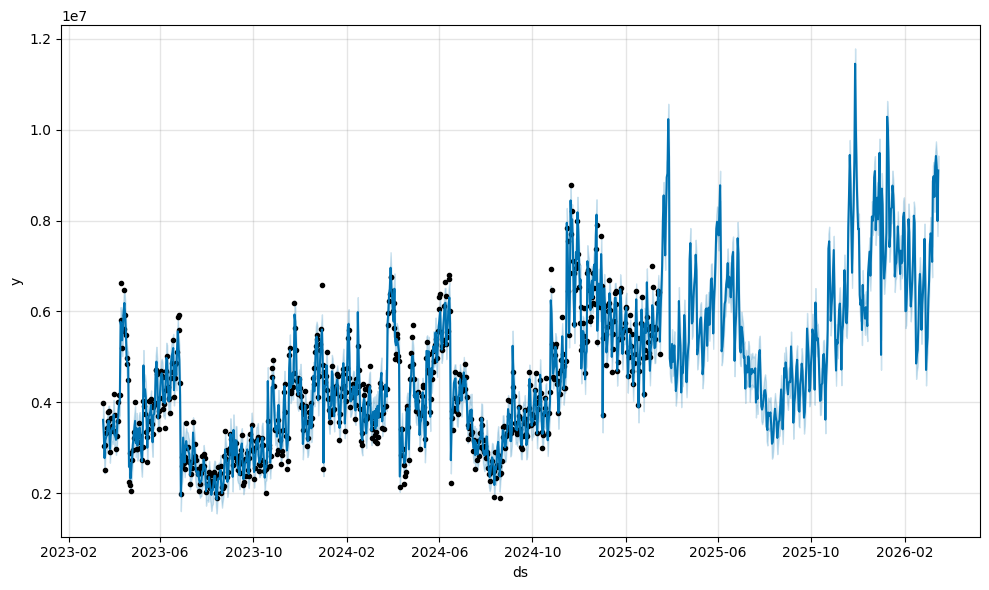

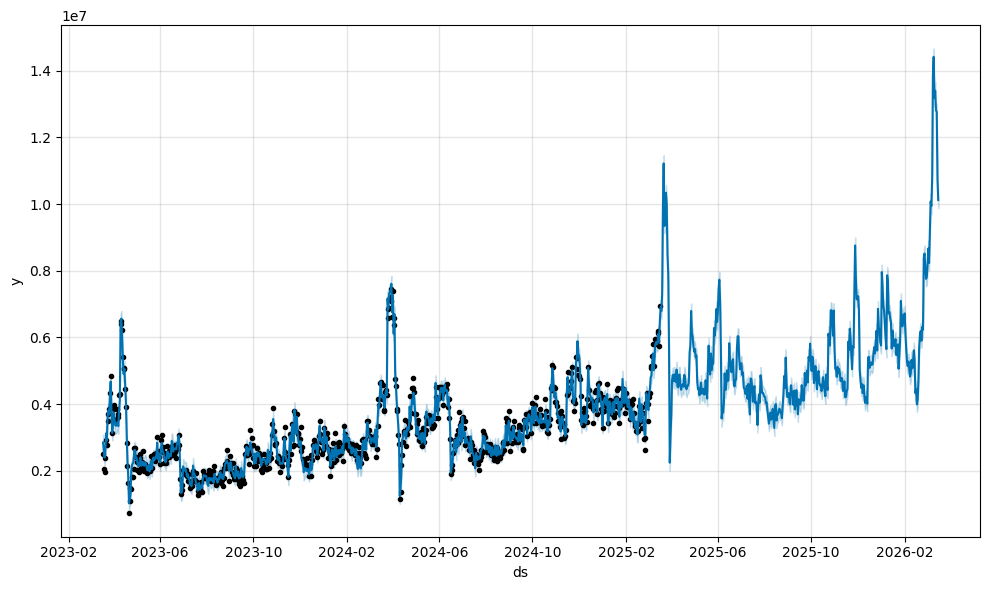

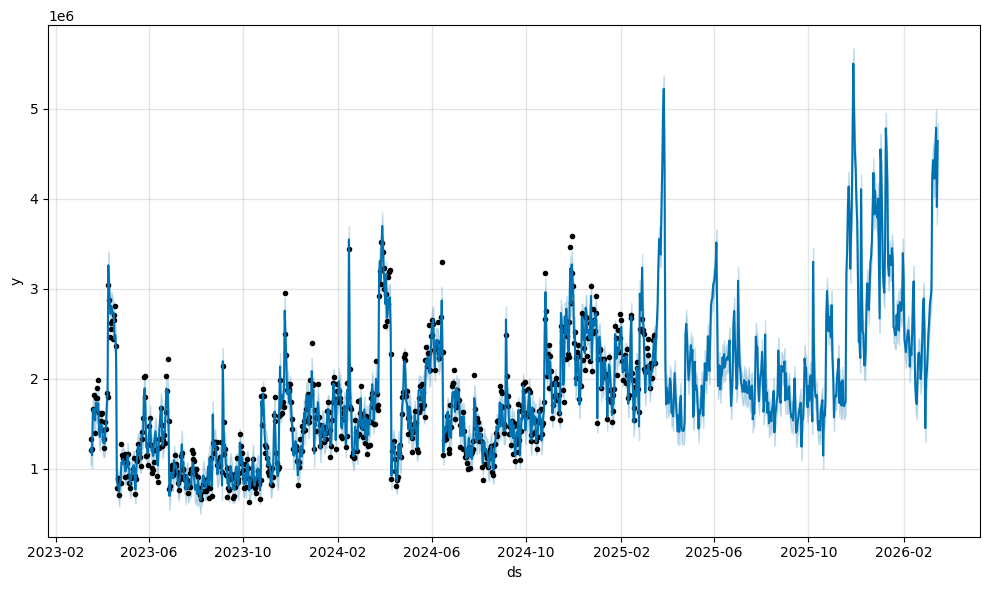

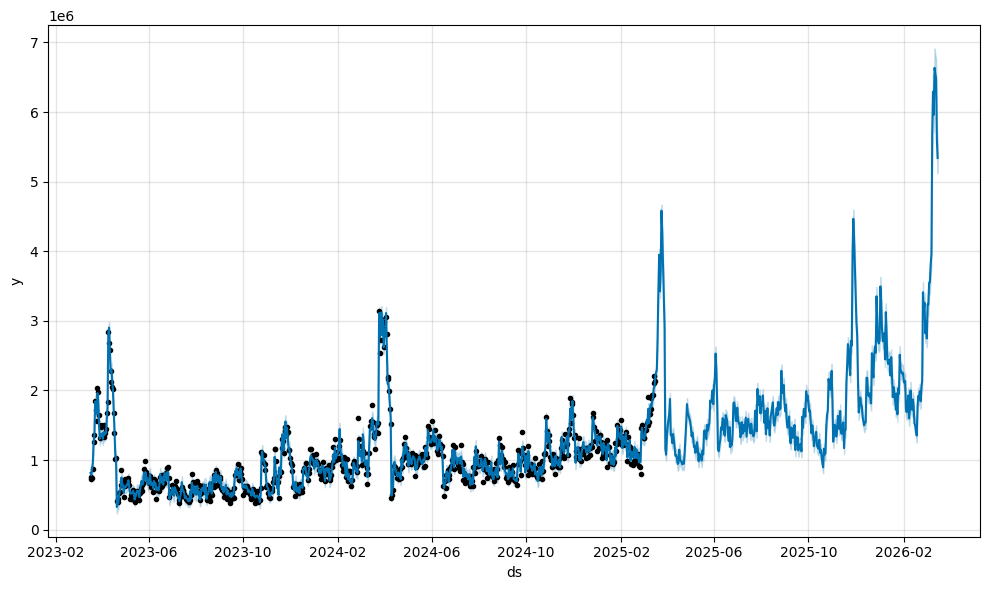

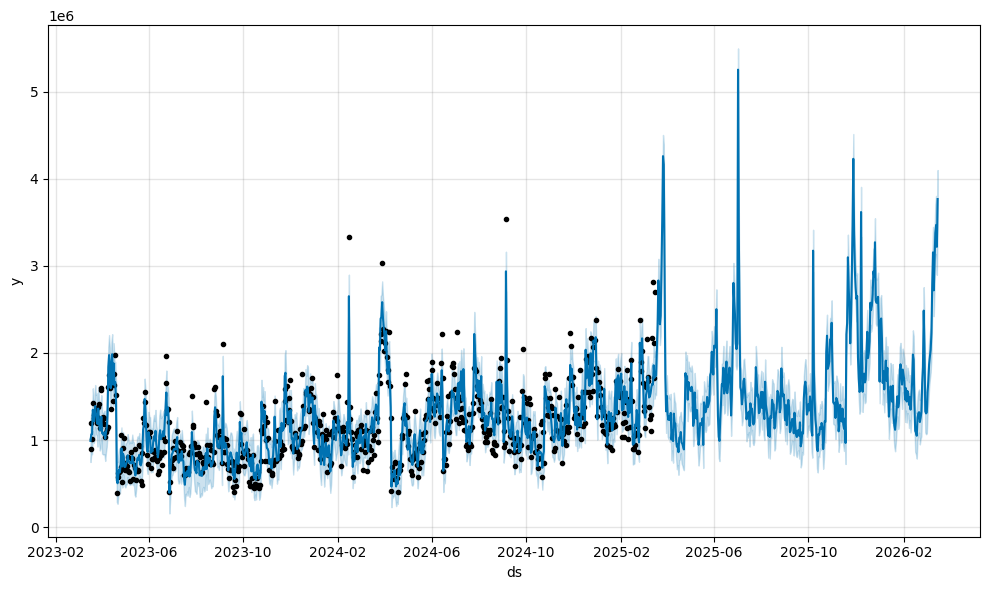

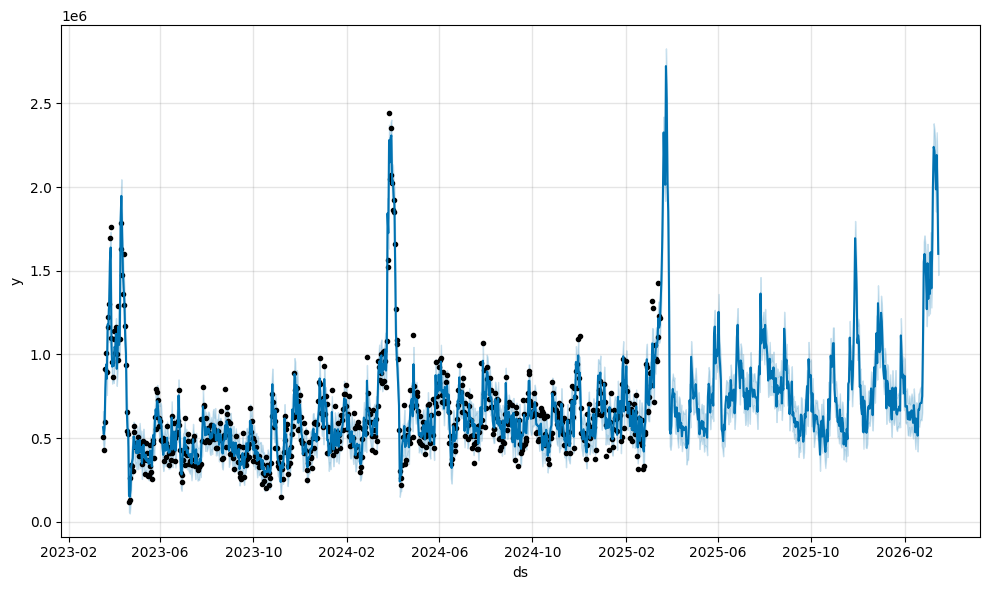

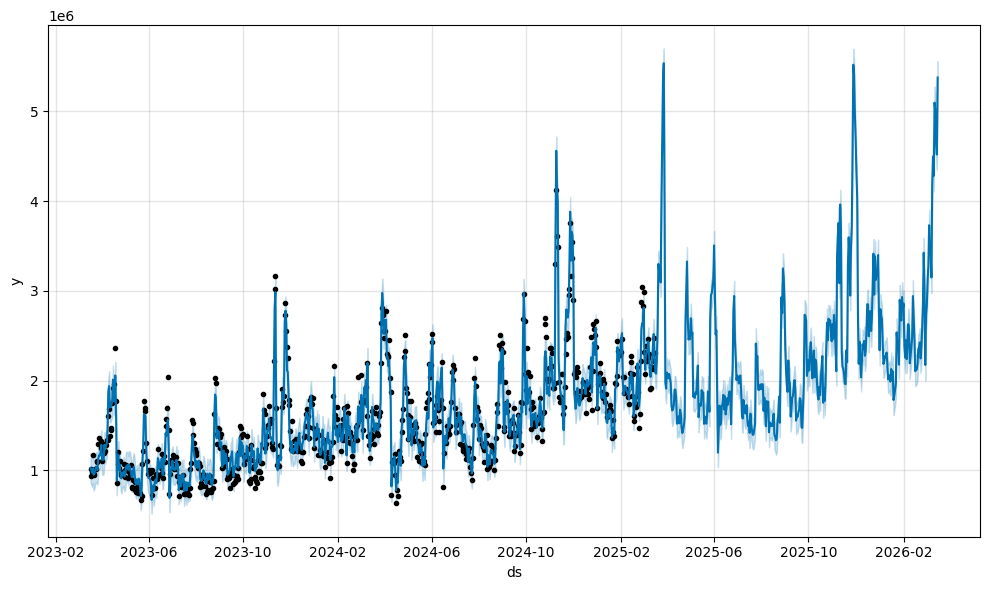

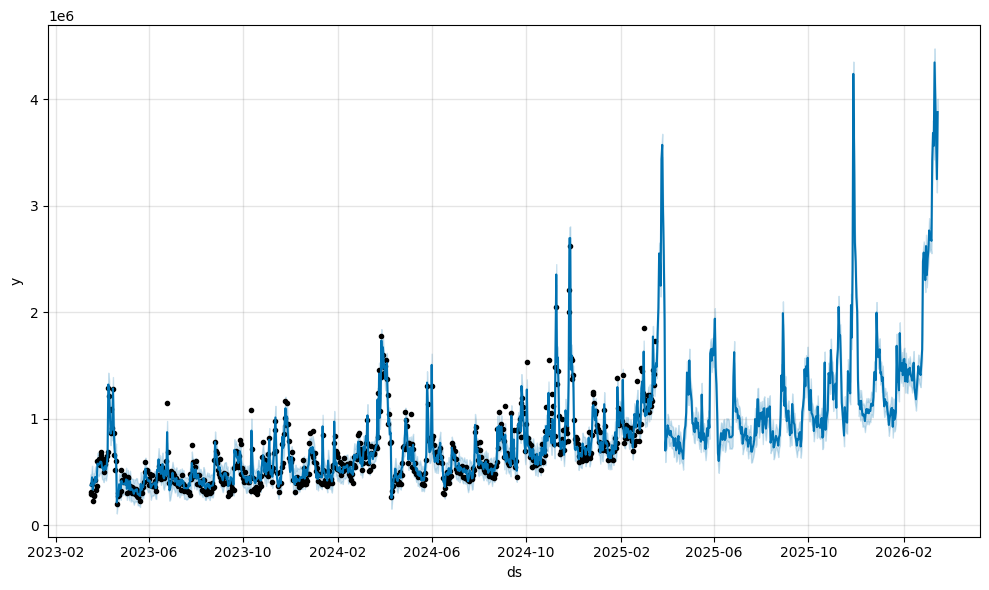

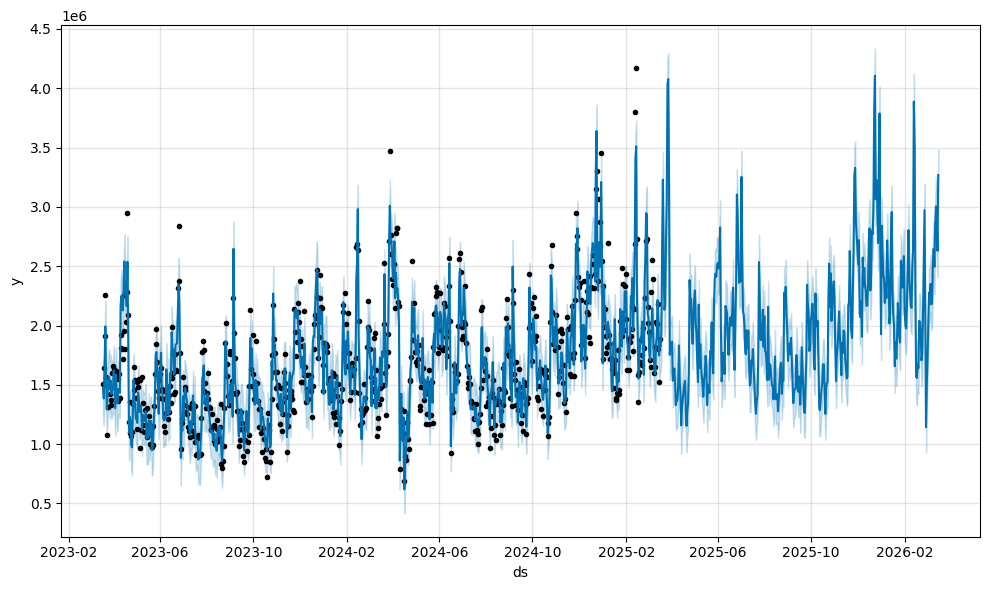

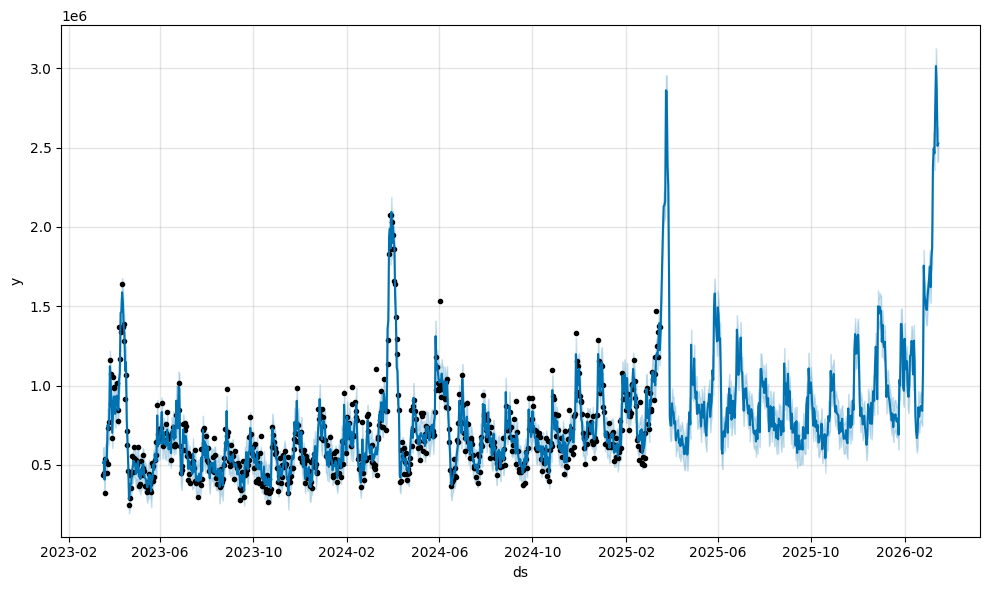

In [80]:
for category, market in combinations:

    print("CURRENT COMBINATION: MARKET: " + market + ", CATEGORY: " + category)
    
    current_train_slice = overall_train[(overall_train.category==category) &(overall_train.market==market)]
    current_test_slice = overall_test[(overall_test.category==category) &(overall_test.market==market)]

    current_train_slice = current_train_slice.rename(columns={'dt': 'ds', 'daily_revenue': 'y'})
    current_train_slice['ds'] = pd.to_datetime(current_train_slice['ds'])

    current_test_slice = current_test_slice.rename(columns={"dt": "ds", "daily_revenue": "y"})
    current_test_slice["ds"] = pd.to_datetime(current_test_slice["ds"])


    c_model = Prophet(seasonality_mode="multiplicative",
                yearly_seasonality=True,
                weekly_seasonality=True,
                daily_seasonality=False)
    
    for reg in regressor_cols:
        c_model.add_regressor(reg, mode='multiplicative')

    c_model.fit(current_train_slice)

    c_future = c_model.make_future_dataframe(periods=365)

    c_regressor_df = pd.concat([current_train_slice, current_test_slice])[["ds"] + regressor_cols]

    c_future = c_future.merge(c_regressor_df, on="ds", how="left")

    c_forecast = c_model.predict(c_future)
    #c_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

    c_fig1 = c_model.plot(c_forecast)

    # merge forecast with actuals
    eval_df = current_test_slice.rename(columns={"dt": "ds", "daily_revenue": "y"})
    eval_df = eval_df.merge(c_forecast[["ds", "yhat"]], on="ds")

    # MAPE
    mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])

    # WMAPE
    wmape = (eval_df["y"] - eval_df["yhat"]).abs().sum() / eval_df["y"].sum()

    # MAE
    mae = (eval_df["y"] - eval_df["yhat"]).abs().mean()

    # Bias
    bias = (eval_df["yhat"] - eval_df["y"]).sum() / eval_df["y"].sum()

    print(f"MAPE:  {mape:.4f}")
    print(f"WMAPE: {wmape:.4f}")
    print(f"MAE:   {mae:.2f}")
    print(f"Bias:  {bias:.4f}")


# supervised regression - LightGBM

In [113]:
import pandas as pd
ml_data = aggregated_order_df.copy()

In [114]:
ml_data['lag_365'] = (
    ml_data.groupby(['category', 'market'])['daily_revenue']
      .shift(365)
)

In [115]:
ml_data['rolling_mean_365'] = (
    ml_data.groupby(['category', 'market'])['daily_revenue']
      .shift(1)
      .rolling(365)
      .mean()
)

In [116]:
ml_data['rolling_std_365'] = (
    ml_data.groupby(['category', 'market'])['daily_revenue']
      .shift(1)
      .rolling(365)
      .std()
)

In [119]:
ml_data['market'] = ml_data['market'].astype('category')
ml_data['category'] = ml_data['category'].astype('category')

In [122]:
ml_data = ml_data.dropna()

In [125]:
ml_data.groupby(["market", "category"]).size()

market    category  
Market_A  Category_A    731
          Category_B    731
          Category_C    731
          Category_D    731
          Category_F    731
Market_B  Category_A    731
          Category_B    731
          Category_C    731
          Category_D    731
          Category_F    731
dtype: int64

In [130]:
cutoff_test_end = pd.to_datetime("2026-03-17")
cutoff_test_start = pd.to_datetime("2025-03-18")

ml_train_df = ml_data[ml_data['dt'] < cutoff_test_start].copy()

ml_test_df = ml_data[(ml_data['dt'] >= cutoff_test_start) & (ml_data['dt'] <= cutoff_test_end)].copy()

print(f"Train Range: {ml_train_df['dt'].min()} to {ml_train_df['dt'].max()}")
print(f"Test Range:  {ml_test_df['dt'].min()} to {ml_test_df['dt'].max()}")

Train Range: 2024-03-17 00:00:00 to 2025-03-17 00:00:00
Test Range:  2025-03-18 00:00:00 to 2026-03-17 00:00:00


In [131]:
len(ml_train_df), len(ml_test_df)

(3660, 3650)

In [143]:
feature_cols = [col for col in ml_train_df.columns if col not in ["dt", "daily_revenue"]]
X_train = ml_train_df[feature_cols]
y_train = ml_train_df["daily_revenue"]

In [144]:
X_test = ml_test_df.drop(columns=["dt", "daily_revenue"])
y_test = ml_test_df["daily_revenue"]

In [147]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    #eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    callbacks=[]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1406
[LightGBM] [Info] Number of data points in the train set: 3660, number of used features: 16
[LightGBM] [Info] Start training from score 1861929.700495


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [148]:
y_pred = model.predict(X_test)

In [152]:
eval_lgbm = ml_test_df[["dt", "daily_revenue"]].copy()
eval_lgbm["yhat"] = y_pred

In [153]:
eval_lgbm_agg = (
    eval_lgbm
    .groupby("dt")[["daily_revenue", "yhat"]]
    .sum()
    .reset_index()
)

In [154]:
from sklearn.metrics import mean_absolute_percentage_error

eval_lgbm_agg = eval_lgbm_agg.rename(columns={
    "daily_revenue": "y",
    "dt": "ds"
})

mape = mean_absolute_percentage_error(eval_lgbm_agg["y"], eval_lgbm_agg["yhat"])
wmape = (eval_lgbm_agg["y"] - eval_lgbm_agg["yhat"]).abs().sum() / eval_lgbm_agg["y"].sum()
mae = (eval_lgbm_agg["y"] - eval_lgbm_agg["yhat"]).abs().mean()
bias = (eval_lgbm_agg["yhat"] - eval_lgbm_agg["y"]).sum() / eval_lgbm_agg["y"].sum()

print(f"LGBM MAPE:  {mape:.4f}")
print(f"LGBM WMAPE: {wmape:.4f}")
print(f"LGBM MAE:   {mae:.2f}")
print(f"LGBM Bias:  {bias:.4f}")

LGBM MAPE:  0.0869
LGBM WMAPE: 0.0967
LGBM MAE:   2364672.10
LGBM Bias:  -0.0875
